# Position Concentration Risk

**Position concentration risk** (also called concentration risk or single-stock risk) is the increased chance of significant losses in your portfolio when too much of your money is tied up in one investment, a small group of investments, a single sector, or even one asset class. In simple terms, instead of your overall returns depending on the performance of many different holdings, they become heavily dependent on just one (or a few). If that position does well, you can see outsized gains—but if it drops sharply, the damage to your whole portfolio is amplified.

**Common thresholds**

Financial professionals often flag a position as “concentrated” when:
- A single stock makes up more than 10% of your total portfolio, or
- A handful of stocks (e.g., five or fewer) account for a large share of your portfolio’s risk (sometimes defined as >30% of total portfolio risk).

It can be intentional (you strongly believe in one company or sector) or unintentional/passive (company stock from your job, inheritance, or a stock that grew so much it now dominates your portfolio). Either way, it creates “single-stock risk,” where events specific to that one company (earnings miss, lawsuit, industry downturn, etc.) hit your finances much harder than they would in a balanced portfolio.

Studies and historical data show concentrated portfolios often deliver higher long-term returns in the best cases, but they also come with much larger losses in the worst cases. Here are some reasons to avoid concetrating too much risk into a few or just a single stock:
- Higher volatility — Your portfolio swings more dramatically.
- Steep drawdowns — One bad event can wipe out years of gains.
- Lack of diversification — You lose the safety net of other assets that might perform well when your concentrated holding struggles.

**Diversification**

The core solution is diversification—spreading your money across different stocks, sectors, asset classes (stocks, bonds, real estate, etc.), geographies, and investment styles. Here are practical ways to do it, such as 1) Set position-sizing rules, 2) Invest across different sectors or asset classes, 3) Portfolio rebalancing etc

In [24]:
import numpy as np
import pandas as pd

from matplotlib import pyplot as plt

#### Case 1: Investing in a single asset

Let us simulate returns of a hypothetical asset and plot its cumulative return over time.

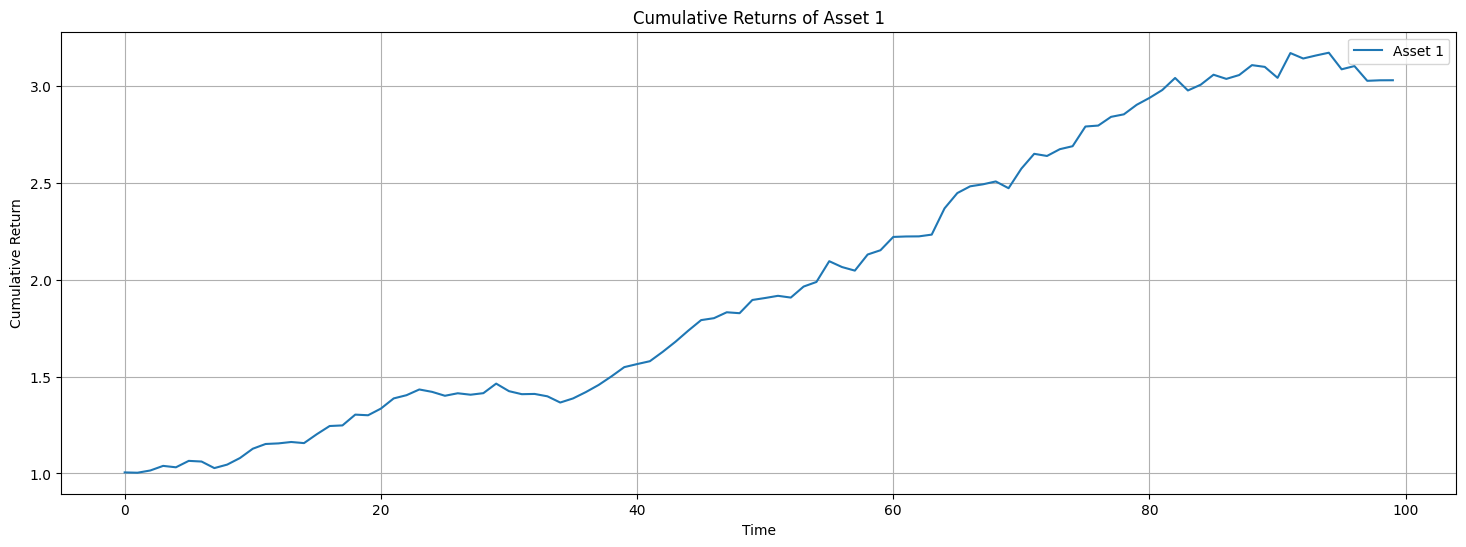

In [25]:
R_1 = np.random.normal(loc=0.01, scale=0.02, size=100)
A_1 = np.cumprod(1+ R_1)

# Plot the cumulative returns
plt.figure(figsize=(18, 6))
plt.plot(A_1, label='Asset 1')
plt.title('Cumulative Returns of Asset 1')
plt.xlabel('Time')
plt.ylabel('Cumulative Return')
plt.legend()
plt.grid()
plt.show()

#### Case 2: Now let's expand this to a basket of N assets and construct a portfolio out of it

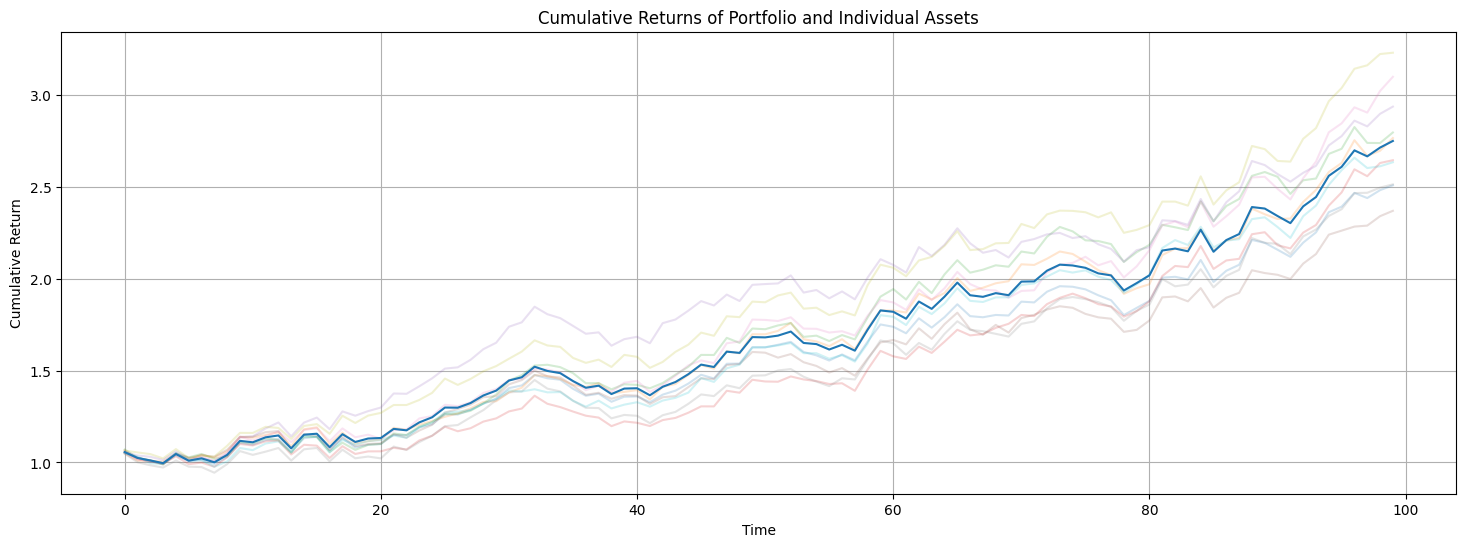

Portfolio Return over time: 1.02%
Average Asset Return over time: 1.02%
Portfolio Volatility: 0.09%
Average Asset Volatility: 3.22%


In [33]:
N = 10

# Initialise the plot
plt.figure(figsize=(18, 6))

returns = np.zeros((N, 100))
assets = np.zeros((N, 100))

R_1 = np.random.normal(1.01, 0.03,100)
returns[0] = R_1
assets[0] = np.cumprod(R_1)
plt.plot(assets[0], label='Asset 1', alpha=0.2)


# Simulate returns and assets for each time step which is R_1 plus some random noise
for t in range(1, N):
  R_t = R_1 + np.random.normal(0.001, 0.01, 100)
  returns[t] = R_t
  assets[t] = np.cumprod(R_t)
  plt.plot(assets[t], label=f'Asset {t+1}', alpha=0.2)
  
R_P = np.mean(returns, axis=1)
P = np.mean(assets, axis=0)

# Plot the cumulative returns of the portfolio
plt.plot(P, label='Portfolio')
plt.title('Cumulative Returns of Portfolio and Individual Assets')
plt.xlabel('Time')
plt.ylabel('Cumulative Return')
plt.grid()
plt.show()

# Print the portfolio returns and standard deviation
print(f'Portfolio Return over time: {R_P[-1] - 1:.2%}')
print(f'Average Asset Return over time: {returns.mean(axis=1)[-1] - 1:.2%}')
print(f'Portfolio Volatility: {np.std(R_P):.2%}')
print(f'Average Asset Volatility: {np.std(returns, axis=1).mean():.2%}')

**Key Insight: Correlation and Portfolio Volatility**

When you add more assets to a portfolio that are **highly correlated** with your existing holdings, the portfolio doesn't behave much differently from holding just the original assets. The assets may appear more diversified on the surface (more names, more positions), but because they tend to move together — up **or** down at roughly the same time — the overall portfolio experiences swings that are very similar in magnitude to a single concentrated bet.

**Important Observation**

The **mean volatility** (standard deviation) of the individual assets remains roughly the same as the volatility of the original concentrated position.
→ You have not actually reduced portfolio risk. In other words, you have essentially placed **the same directional bet multiple times** instead of spreading risk across uncorrelated or lowly correlated assets.

#### Case 3: Investing in many uncorrelated assets and constructing a portfolio from them

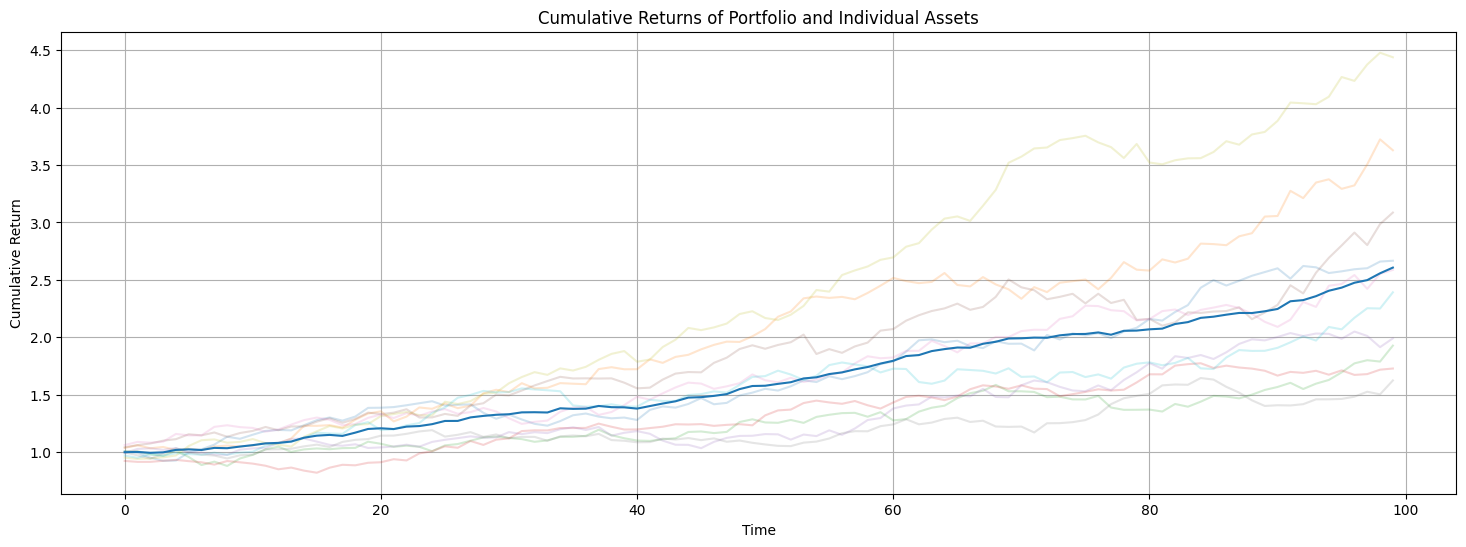

Portfolio Return over time: 2.82%
Average Asset Return over time: 2.82%
Portfolio Volatility: 0.93%
Average Asset Volatility: 2.59%


In [34]:
N = 10

# Initialise the plot
plt.figure(figsize=(18, 6))

assets = np.zeros((N, 100))
returns = np.zeros((N, 100))

for i in range(N):
  R_i = np.random.normal(1.01, 0.03, 100)
  returns[i] = R_i
  assets[i] = np.cumprod(R_i)
  plt.plot(assets[i], label=f'Asset {i+1}', alpha=0.2)
  
R_P = np.mean(returns, axis=0)
P = np.mean(assets, axis=0)

# Plot the cumulative returns of the portfolio
plt.plot(P, label='Portfolio')
plt.title('Cumulative Returns of Portfolio and Individual Assets')
plt.xlabel('Time')
plt.ylabel('Cumulative Return')
plt.grid()
plt.show()

# Print the portfolio returns and standard deviation
print(f'Portfolio Return over time: {R_P[-1] - 1:.2%}')
print(f'Average Asset Return over time: {returns.mean(axis=0)[-1] - 1:.2%}')
print(f'Portfolio Volatility: {np.std(R_P):.2%}')
print(f'Average Asset Volatility: {np.std(returns, axis=0).mean():.2%}')

As we can see, holding more uncorrelated assets smooths out our portfolio. When one is down, the others are no more likely to be down, so the overall volatility is lower. 

In fact, we can see the power of diversification by plotting the standard deviation of varying portfolios (different asset count), and see how the standard deviation varies as we increase the number of assets.

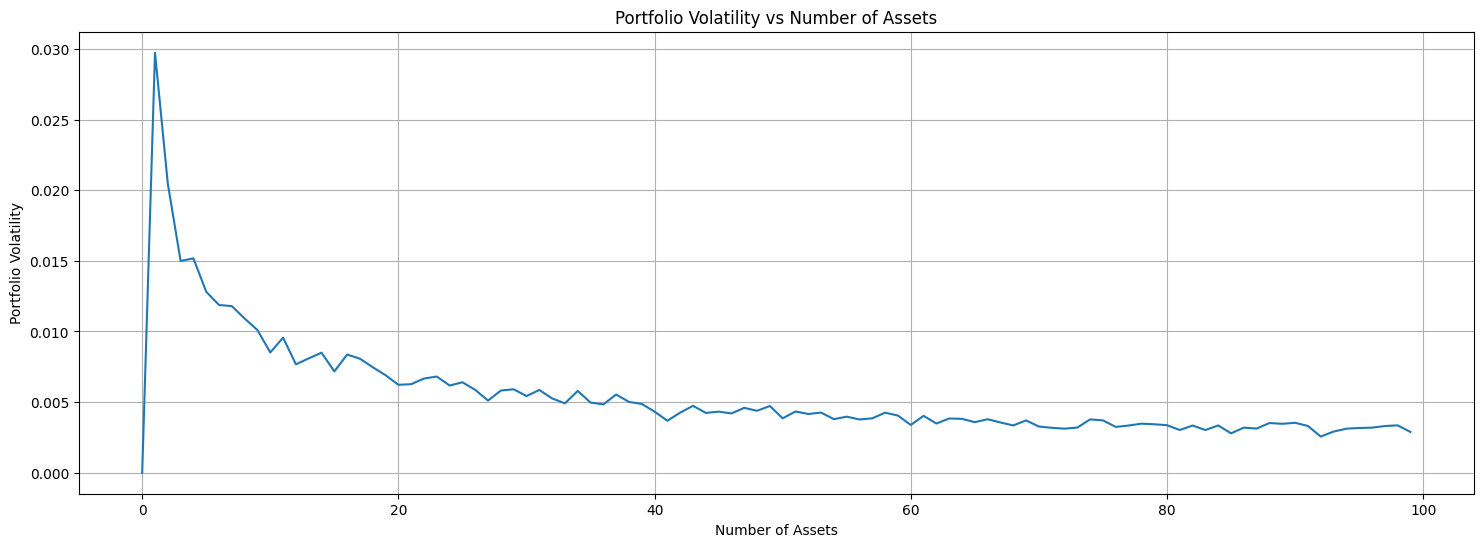

In [35]:
portfolio_volatilities = np.zeros((100, 1))
for N in range(1, 100):
  assets = np.zeros((N, 100))
  returns = np.zeros((N, 100))
  for i in range(N):
    R_i = np.random.normal(1.01, 0.03, 100)
    returns[i] = R_i
  R_P = np.mean(returns, axis=0)
  portfolio_volatilities[N] = np.std(R_P)
  
# Plot the portfolio volatility as a function of the number of assets
plt.figure(figsize=(18, 6))
plt.plot(portfolio_volatilities, label='Portfolio Volatility')
plt.title('Portfolio Volatility vs Number of Assets')
plt.xlabel('Number of Assets')
plt.ylabel('Portfolio Volatility')
plt.grid()
plt.show()

As we can see above, the standard deviation of the portfolio decreases as we increase the number of assets in our holdings.